This notebook is for **geometry-specific analysis of the Cs runs**, especially the thickness-effect runs.

It assumes you have already built:
- `compton_analysis_outputs/compton_feature_fits_all.csv`
- `manual_peak_fits_all.csv`
- `processed_data/...`

The goal here is not just to plot one thing, but to separate several physically different effects:

1. **front attenuation** of the main beam,
2. **behind-source backscatter enhancement**,
3. shifts in the **backscatter peak** and **Compton edge**,
4. changes in the **slope / width of the Compton continuum**,
5. changes in the **photopeak relative to the low-energy structure**.

WARNING: the `in_front` runs where the 662 keV peak gets lost should not be forced into the same photopeak-based observables as the cleaner runs. For those, continuum-based observables are more trustworthy.

In [5]:

# -----------------------------
# IMPORTS
# -----------------------------

import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (9, 5)

In [6]:

# -----------------------------
# FILE LOCATIONS
# -----------------------------

ROOT = Path("processed_data")
COMPTON_MASTER = Path("compton_analysis_outputs") / "compton_feature_fits_all.csv"
MANUAL_PEAK_FILE = Path("peak_analysis_outputs") / "manual_peak_fits_all.csv"
BACKGROUND_FILE = ROOT / "calibration" / "background_550PM_feb26_213PM_mar3.csv"

print("Compton master exists:", COMPTON_MASTER.exists())
print("Manual peak file exists:", MANUAL_PEAK_FILE.exists())
print("Background exists:", BACKGROUND_FILE.exists())

Compton master exists: True
Manual peak file exists: True
Background exists: True


In [7]:

# -----------------------------
# LOAD TABLES
# -----------------------------

compton_df = pd.read_csv(COMPTON_MASTER)
peak_df = pd.read_csv(MANUAL_PEAK_FILE)

print("Compton rows:", len(compton_df))
print("Peak rows:", len(peak_df))

display(compton_df.head())
display(peak_df.head())

Compton rows: 38
Peak rows: 138


,file,day,feature_label,center_ADC,center_ADC_err,sigma_ADC,sigma_ADC_err,amplitude_counts_per_s,amplitude_counts_per_s_err,gaussian_area_counts,gaussian_area_counts_err,fit_xmin,fit_xmax,background_slope,background_slope_err,background_intercept,background_intercept_err,fit_chi2,fit_redchi2,compton_region_length_ADC,compton_region_length_ADC_err,compton_region_slope_counts_per_s_per_ADC,compton_region_slope_err,compton_region_intercept,compton_region_intercept_err,compton_region_redchi2,compton_region_average_drop_per_ADC
0,calibration/daily/Cs_21.9C_preamp0_mar5.csv,mar5,backscatter_peak,152.635832,5.983856,10.624223,9.856419,3.121502,2.471694,83.128658,101.392320,132.99,177.87,0.014230,0.063609,2.922854,11.555582,0.085901,0.002148,187.911197,23.984740,-0.011843,0.000815,7.674373,0.210897,0.072974,-0.011843
1,calibration/daily/Cs_21.9C_preamp0_mar5.csv,mar5,compton_edge,340.547030,23.226304,12.100073,37.412921,1.061078,3.765257,32.182905,151.472478,313.83,358.71,-0.031632,0.089709,13.955308,27.213424,2.768360,0.069209,187.911197,23.984740,-0.011843,0.000815,7.674373,0.210897,0.072974,-0.011843
2,calibration/daily/Cs_22.0C_preamp0_mar3.csv,mar3,backscatter_peak,155.014473,5.257236,11.239558,8.076281,2.603258,1.370986,73.342604,65.339936,130.35,183.15,0.007544,0.033468,2.775268,5.980826,0.072134,0.001503,199.731957,2180.464171,-0.009451,0.000618,5.919690,0.166310,0.067545,-0.009451
3,calibration/daily/Cs_22.0C_preamp0_mar3.csv,mar3,compton_edge,354.746429,2180.457833,39.426661,2840.375276,8.288705,1444.012950,819.155963,154429.384151,319.11,354.75,-0.092211,12.244989,26.786674,2903.329319,1.798890,0.059963,199.731957,2180.464171,-0.009451,0.000618,5.919690,0.166310,0.067545,-0.009451
4,calibration/daily/Cs_22.4C_preamp0_feb26.csv,feb26,backscatter_peak,143.535067,3.679579,7.661727,5.157910,4.234137,1.942617,81.317042,66.247231,122.43,163.35,0.080216,0.066423,0.456207,9.307569,8.467742,0.235215,196.968899,187.543882,-0.020528,0.001182,16.133728,0.300005,0.075876,-0.020528


,file,group_id,peak_in_group,n_peaks_in_group,theoretical_energy_keV,theoretical_energy_keV_err,clicked_center_ADC,center_ADC,center_ADC_err,sigma_ADC,sigma_ADC_err,amplitude_counts_per_s,amplitude_counts_per_s_err,gaussian_area_counts,fit_xmin,fit_xmax,background_slope,background_intercept
0,calibration/daily/Co60_21.9C_preamp100_mar5.csv,1,1,2,1173.228,0.003,652,649.075865,0.223619,14.749785,0.297055,5.958860,0.087479,220.312327,597,792,-0.005121,3.997337
1,calibration/daily/Co60_21.9C_preamp100_mar5.csv,1,2,2,1332.494,0.002,732,734.205555,0.282125,16.329201,0.369967,5.032531,0.083152,205.987725,597,792,-0.005121,3.997337
2,calibration/daily/Co60_22.4C_preamp100_feb26.csv,1,1,2,1173.228,0.003,652,651.142231,0.184083,14.864290,0.239054,14.550275,0.172824,542.132295,596,815,-0.011299,9.124645
3,calibration/daily/Co60_22.4C_preamp100_feb26.csv,1,2,2,1332.494,0.002,740,737.334233,0.229609,16.270415,0.269837,12.265332,0.158176,500.227869,596,815,-0.011299,9.124645
4,calibration/daily/Co60_22.5C_preamp100_mar3.csv,1,1,2,1173.228,0.003,645,648.684317,0.222826,14.592461,0.292220,4.466219,0.065576,163.364814,596,790,-0.003907,3.043445


In [8]:

# -----------------------------
# PARSE GEOMETRY METADATA
# -----------------------------

def _extract_float(pattern, text):
    m = re.search(pattern, str(text))
    if not m:
        return np.nan
    try:
        return float(m.group(1))
    except Exception:
        return np.nan

def parse_geometry_info(relpath):
    rel = Path(relpath).as_posix()
    lower = rel.lower()
    name = Path(rel).name

    if "thickness_effects_behind" in lower:
        geometry_position = "behind"
    elif "thickness_effects_in_front" in lower:
        geometry_position = "in_front"
    else:
        geometry_position = "standard"

    if "/pb" in lower or name.startswith("Pb_") or name.startswith("pb_"):
        material = "Pb"
    elif "/al" in lower or name.startswith("Al_") or name.startswith("al_"):
        material = "Al"
    else:
        material = "none"

    if "control" in lower or "booster" in lower:
        run_role = "control"
    else:
        run_role = "measurement"

    thickness_cm = _extract_float(r"([0-9]+(?:\.[0-9]+)?)cmthick", name)
    pmt_distance_cm = _extract_float(r"([0-9]+(?:\.[0-9]+)?)cmpmt", name)
    source_to_pmt_cm = _extract_float(r"([0-9]+(?:\.[0-9]+)?)cmpmt_tosource", name)

    if np.isnan(source_to_pmt_cm) and geometry_position == "in_front":
        source_to_pmt_cm = pmt_distance_cm

    if "feb_26" in lower:
        day = "feb26"
    elif "mar_3" in lower:
        day = "mar3"
    elif "mar_5" in lower:
        day = "mar5"
    elif "feb_24" in lower:
        day = "feb24"
    else:
        day = None

    return {
        "geometry_position": geometry_position,
        "material": material,
        "run_role": run_role,
        "thickness_cm": thickness_cm,
        "pmt_distance_cm": pmt_distance_cm,
        "source_to_pmt_cm": source_to_pmt_cm,
        "day": day,
    }

geom_meta = pd.DataFrame([{"file": f, **parse_geometry_info(f)} for f in sorted(set(compton_df["file"]))])
display(geom_meta.head(20))

,file,geometry_position,material,run_role,thickness_cm,pmt_distance_cm,source_to_pmt_cm,day
0,calibration/daily/Cs_21.9C_preamp0_mar5.csv,standard,none,measurement,NaN,NaN,NaN,None
1,calibration/daily/Cs_22.0C_preamp0_mar3.csv,standard,none,measurement,NaN,NaN,NaN,None
2,calibration/daily/Cs_22.4C_preamp0_feb26.csv,standard,none,measurement,NaN,NaN,NaN,None
3,calibration/feb_24/preamp_0/Cs_22.1C_preamp0_f...,standard,none,measurement,NaN,NaN,NaN,feb24
4,cs gain setting/Cs_possible_calcurve_feb_24.csv,standard,none,measurement,NaN,NaN,NaN,feb24
5,cs gain setting/Cs_trial_feb_19.csv,standard,none,measurement,NaN,NaN,NaN,None
6,data/feb_26/cs137/Cs_22.4C_feb26_run1.csv,standard,none,measurement,NaN,NaN,NaN,feb26
7,data/mar_3/cs137/Cs_22.5C_mar3_run1.csv,standard,none,measurement,NaN,NaN,NaN,mar3
8,data/mar_5/cs137/Cs_21.9C_mar5_run1.csv,standard,none,measurement,NaN,NaN,NaN,mar5
9,data/thickness_effects_behind/Al thickness/Al_...,behind,Al,measurement,1.3,16.0,NaN,None


In [9]:

# -----------------------------
# WIDE COMPTON TABLE
# -----------------------------

wide = (
    compton_df
    .pivot_table(
        index="file",
        columns="feature_label",
        values=[
            "center_ADC",
            "center_ADC_err",
            "sigma_ADC",
            "sigma_ADC_err",
            "amplitude_counts_per_s",
            "amplitude_counts_per_s_err",
            "gaussian_area_counts",
            "gaussian_area_counts_err",
            "fit_redchi2",
            "compton_region_length_ADC",
            "compton_region_length_ADC_err",
            "compton_region_slope_counts_per_s_per_ADC",
            "compton_region_slope_err",
            "compton_region_redchi2",
            "compton_region_average_drop_per_ADC",
        ],
        aggfunc="first",
    )
)

wide.columns = [
    f"{a}__{b}" if isinstance(b, str) and b else str(a)
    for a, b in wide.columns.to_flat_index()
]
wide = wide.reset_index()

geom_df = wide.merge(geom_meta, on="file", how="left")
display(geom_df.head())

,file,amplitude_counts_per_s__backscatter_peak,amplitude_counts_per_s__compton_edge,amplitude_counts_per_s_err__backscatter_peak,amplitude_counts_per_s_err__compton_edge,center_ADC__backscatter_peak,center_ADC__compton_edge,center_ADC_err__backscatter_peak,center_ADC_err__compton_edge,compton_region_average_drop_per_ADC__backscatter_peak,compton_region_average_drop_per_ADC__compton_edge,compton_region_length_ADC__backscatter_peak,compton_region_length_ADC__compton_edge,compton_region_length_ADC_err__backscatter_peak,compton_region_length_ADC_err__compton_edge,compton_region_redchi2__backscatter_peak,compton_region_redchi2__compton_edge,compton_region_slope_counts_per_s_per_ADC__backscatter_peak,compton_region_slope_counts_per_s_per_ADC__compton_edge,compton_region_slope_err__backscatter_peak,compton_region_slope_err__compton_edge,fit_redchi2__backscatter_peak,fit_redchi2__compton_edge,gaussian_area_counts__backscatter_peak,gaussian_area_counts__compton_edge,gaussian_area_counts_err__backscatter_peak,gaussian_area_counts_err__compton_edge,sigma_ADC__backscatter_peak,sigma_ADC__compton_edge,sigma_ADC_err__backscatter_peak,sigma_ADC_err__compton_edge,geometry_position,material,run_role,thickness_cm,pmt_distance_cm,source_to_pmt_cm,day
0,calibration/daily/Cs_21.9C_preamp0_mar5.csv,3.121502,1.061078,2.471694,3.765257,152.635832,340.547030,5.983856,23.226304,-0.011843,-0.011843,187.911197,187.911197,23.984740,23.984740,0.072974,0.072974,-0.011843,-0.011843,0.000815,0.000815,0.002148,0.069209,83.128658,32.182905,101.392320,151.472478,10.624223,12.100073,9.856419,37.412921,standard,none,measurement,NaN,NaN,NaN,None
1,calibration/daily/Cs_22.0C_preamp0_mar3.csv,2.603258,8.288705,1.370986,1444.012950,155.014473,354.746429,5.257236,2180.457833,-0.009451,-0.009451,199.731957,199.731957,2180.464171,2180.464171,0.067545,0.067545,-0.009451,-0.009451,0.000618,0.000618,0.001503,0.059963,73.342604,819.155963,65.339936,154429.384151,11.239558,39.426661,8.076281,2840.375276,standard,none,measurement,NaN,NaN,NaN,None
2,calibration/daily/Cs_22.4C_preamp0_feb26.csv,4.234137,4.277581,1.942617,114.711629,143.535067,340.503966,3.679579,187.507783,-0.020528,-0.020528,196.968899,196.968899,187.543882,187.543882,0.075876,0.075876,-0.020528,-0.020528,0.001182,0.001182,0.235215,0.053216,81.317042,194.538697,66.247231,5675.833450,7.661727,18.143366,5.157910,208.516451,standard,none,measurement,NaN,NaN,NaN,None
3,calibration/feb_24/preamp_0/Cs_22.1C_preamp0_f...,4.578092,0.651680,1.638804,2.024122,146.828851,332.599207,3.600527,16.366037,-0.019199,-0.019199,185.770356,185.770356,16.757415,16.757415,0.075770,0.075770,-0.019199,-0.019199,0.001151,0.001151,0.141410,0.062242,113.612982,9.340201,71.180257,48.028259,9.900418,5.717835,5.090598,23.431925,standard,none,measurement,NaN,NaN,NaN,feb24
4,cs gain setting/Cs_possible_calcurve_feb_24.csv,5.403736,1.400280,4.718535,7.716039,144.965989,336.736137,5.725635,30.609912,-0.018930,-0.018930,191.770148,191.770148,31.140803,31.140803,0.083252,0.083252,-0.018930,-0.018930,0.001155,0.001155,0.165788,0.058936,149.777887,36.045472,186.460818,248.080973,11.057671,10.269418,9.811705,42.346937,standard,none,measurement,NaN,NaN,NaN,feb24


In [10]:

# -----------------------------
# PHOTOPEAK TABLE FROM MANUAL PEAK FITS
# -----------------------------

photopeak_df = peak_df.copy()

# keep only likely Cs photopeak rows
photopeak_df = photopeak_df[
    np.isfinite(photopeak_df["theoretical_energy_keV"]) &
    np.isclose(photopeak_df["theoretical_energy_keV"], 661.657, atol=5.0)
].copy()

photopeak_df = (
    photopeak_df.sort_values(["file", "amplitude_counts_per_s"], ascending=[True, False])
    .drop_duplicates(subset=["file"])
)

photopeak_df = photopeak_df[[
    "file",
    "center_ADC",
    "center_ADC_err",
    "sigma_ADC",
    "sigma_ADC_err",
    "amplitude_counts_per_s",
    "amplitude_counts_per_s_err",
    "gaussian_area_counts",
]].rename(columns={
    "center_ADC": "photopeak_center_ADC",
    "center_ADC_err": "photopeak_center_ADC_err",
    "sigma_ADC": "photopeak_sigma_ADC",
    "sigma_ADC_err": "photopeak_sigma_ADC_err",
    "amplitude_counts_per_s": "photopeak_amplitude_counts_per_s",
    "amplitude_counts_per_s_err": "photopeak_amplitude_counts_per_s_err",
    "gaussian_area_counts": "photopeak_area_counts",
})

analysis_df = geom_df.merge(photopeak_df, on="file", how="left")
display(analysis_df.head(20))

,file,amplitude_counts_per_s__backscatter_peak,amplitude_counts_per_s__compton_edge,amplitude_counts_per_s_err__backscatter_peak,amplitude_counts_per_s_err__compton_edge,center_ADC__backscatter_peak,center_ADC__compton_edge,center_ADC_err__backscatter_peak,center_ADC_err__compton_edge,compton_region_average_drop_per_ADC__backscatter_peak,compton_region_average_drop_per_ADC__compton_edge,compton_region_length_ADC__backscatter_peak,compton_region_length_ADC__compton_edge,compton_region_length_ADC_err__backscatter_peak,compton_region_length_ADC_err__compton_edge,compton_region_redchi2__backscatter_peak,compton_region_redchi2__compton_edge,compton_region_slope_counts_per_s_per_ADC__backscatter_peak,compton_region_slope_counts_per_s_per_ADC__compton_edge,compton_region_slope_err__backscatter_peak,compton_region_slope_err__compton_edge,fit_redchi2__backscatter_peak,fit_redchi2__compton_edge,gaussian_area_counts__backscatter_peak,gaussian_area_counts__compton_edge,gaussian_area_counts_err__backscatter_peak,gaussian_area_counts_err__compton_edge,sigma_ADC__backscatter_peak,sigma_ADC__compton_edge,sigma_ADC_err__backscatter_peak,sigma_ADC_err__compton_edge,geometry_position,material,run_role,thickness_cm,pmt_distance_cm,source_to_pmt_cm,day,photopeak_center_ADC,photopeak_center_ADC_err,photopeak_sigma_ADC,photopeak_sigma_ADC_err,photopeak_amplitude_counts_per_s,photopeak_amplitude_counts_per_s_err,photopeak_area_counts
0,calibration/daily/Cs_21.9C_preamp0_mar5.csv,3.121502,1.061078,2.471694,3.765257,152.635832,340.547030,5.983856,23.226304,-0.011843,-0.011843,187.911197,187.911197,23.984740,23.984740,0.072974,0.072974,-0.011843,-0.011843,0.000815,0.000815,0.002148,0.069209,83.128658,32.182905,101.392320,151.472478,10.624223,12.100073,9.856419,37.412921,standard,none,measurement,NaN,NaN,NaN,None,505.179638,0.180231,14.941343,0.204523,38.228217,0.406552,1431.738174
1,calibration/daily/Cs_22.0C_preamp0_mar3.csv,2.603258,8.288705,1.370986,1444.012950,155.014473,354.746429,5.257236,2180.457833,-0.009451,-0.009451,199.731957,199.731957,2180.464171,2180.464171,0.067545,0.067545,-0.009451,-0.009451,0.000618,0.000618,0.001503,0.059963,73.342604,819.155963,65.339936,154429.384151,11.239558,39.426661,8.076281,2840.375276,standard,none,measurement,NaN,NaN,NaN,None,505.671076,0.183272,14.848871,0.208210,28.570616,0.309751,1063.415433
2,calibration/daily/Cs_22.4C_preamp0_feb26.csv,4.234137,4.277581,1.942617,114.711629,143.535067,340.503966,3.679579,187.507783,-0.020528,-0.020528,196.968899,196.968899,187.543882,187.543882,0.075876,0.075876,-0.020528,-0.020528,0.001182,0.001182,0.235215,0.053216,81.317042,194.538697,66.247231,5675.833450,7.661727,18.143366,5.157910,208.516451,standard,none,measurement,NaN,NaN,NaN,None,503.121706,0.164891,15.484003,0.184904,91.451228,0.857490,3549.463506
3,calibration/feb_24/preamp_0/Cs_22.1C_preamp0_f...,4.578092,0.651680,1.638804,2.024122,146.828851,332.599207,3.600527,16.366037,-0.019199,-0.019199,185.770356,185.770356,16.757415,16.757415,0.075770,0.075770,-0.019199,-0.019199,0.001151,0.001151,0.141410,0.062242,113.612982,9.340201,71.180257,48.028259,9.900418,5.717835,5.090598,23.431925,standard,none,measurement,NaN,NaN,NaN,feb24,505.196312,0.194260,15.245587,0.222905,74.002003,0.826398,2827.988026
4,cs gain setting/Cs_possible_calcurve_feb_24.csv,5.403736,1.400280,4.718535,7.716039,144.965989,336.736137,5.725635,30.609912,-0.018930,-0.018930,191.770148,191.770148,31.140803,31.140803,0.083252,0.083252,-0.018930,-0.018930,0.001155,0.001155,0.165788,0.058936,149.777887,36.045472,186.460818,248.080973,11.057671,10.269418,9.811705,42.346937,standard,none,measurement,NaN,NaN,NaN,feb24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,cs gain setting/Cs_trial_feb_19.csv,324.216360,36.994570,2046.278361,1002.896916,129.030000,261.376175,48.615707,148.580229,-0.104232,-0.104232,132.346175,132.346175,156.331607,156.331607,0.309695,0.309695,-0.104232,-0.104232,0.008247,0.008247,0.915242,0.246486,17674.477357,1410.345279,118870.298090,40897.4057

In [11]:

# -----------------------------
# DERIVED OBSERVABLES
# -----------------------------

analysis_df["backscatter_to_photopeak_area_ratio"] = (
    analysis_df["gaussian_area_counts__backscatter_peak"] /
    analysis_df["photopeak_area_counts"]
)

analysis_df["backscatter_to_photopeak_amp_ratio"] = (
    analysis_df["amplitude_counts_per_s__backscatter_peak"] /
    analysis_df["photopeak_amplitude_counts_per_s"]
)

analysis_df["edge_minus_backscatter_ADC"] = (
    analysis_df["center_ADC__compton_edge"] -
    analysis_df["center_ADC__backscatter_peak"]
)

analysis_df["photopeak_minus_edge_ADC"] = (
    analysis_df["photopeak_center_ADC"] -
    analysis_df["center_ADC__compton_edge"]
)

display(analysis_df[
    [
        "file",
        "geometry_position",
        "material",
        "thickness_cm",
        "center_ADC__backscatter_peak",
        "center_ADC__compton_edge",
        "photopeak_center_ADC",
        "backscatter_to_photopeak_area_ratio",
        "backscatter_to_photopeak_amp_ratio",
        "edge_minus_backscatter_ADC",
        "photopeak_minus_edge_ADC",
        "compton_region_slope_counts_per_s_per_ADC__backscatter_peak",
    ]
].head(20))

,file,geometry_position,material,thickness_cm,center_ADC__backscatter_peak,center_ADC__compton_edge,photopeak_center_ADC,backscatter_to_photopeak_area_ratio,backscatter_to_photopeak_amp_ratio,edge_minus_backscatter_ADC,photopeak_minus_edge_ADC,compton_region_slope_counts_per_s_per_ADC__backscatter_peak
0,calibration/daily/Cs_21.9C_preamp0_mar5.csv,standard,none,NaN,152.635832,340.547030,505.179638,0.058061,0.081654,187.911197,164.632608,-0.011843
1,calibration/daily/Cs_22.0C_preamp0_mar3.csv,standard,none,NaN,155.014473,354.746429,505.671076,0.068969,0.091117,199.731957,150.924647,-0.009451
2,calibration/daily/Cs_22.4C_preamp0_feb26.csv,standard,none,NaN,143.535067,340.503966,503.121706,0.022910,0.046299,196.968899,162.617741,-0.020528
3,calibration/feb_24/preamp_0/Cs_22.1C_preamp0_f...,standard,none,NaN,146.828851,332.599207,505.196312,0.040174,0.061864,185.770356,172.597105,-0.019199
4,cs gain setting/Cs_possible_calcurve_feb_24.csv,standard,none,NaN,144.965989,336.736137,NaN,NaN,NaN,191.770148,NaN,-0.018930
5,cs gain setting/Cs_trial_feb_19.csv,standard,none,NaN,129.030000,261.376175,NaN,NaN,NaN,132.346175,NaN,-0.104232
6,data/feb_26/cs137/Cs_22.4C_feb26_run1.csv,standard,none,NaN,138.219695,333.658943,503.190803,0.146978,0.144135,195.439247,169.531860,-0.023579
7,data/mar_3/cs137/Cs_22.5C_mar3_run1.csv,standard,none,NaN,154.441353,324.390000,505.105909,0.077533,0.097003,169.948647,180.715909,-0.012078
8,data/mar_5/cs137/Cs_21.9C_mar5_run1.csv,standard,none,NaN,151.985613,354.748548,505.214458,0.052348,0.079173,202.762934,150.465910,-0.011318
9,data/thickness_effects_behind/Al thickness/Al_...,behind,Al,1.3,138.811329,341.550000,497.431835,0.017715,0.030050,202.738671,155.881835,-0.026486


## Suggested analyses to prioritize (?)

### 1. Backscatter enhancement vs thickness
For the `behind` runs, plot:
- backscatter area,
- backscatter amplitude,
- backscatter / photopeak ratio,

against thickness, separated by material.

This is the cleanest direct test for whether adding material behind the source enhances return-scattered events without simply blocking the main beam.

### 2. Front-obstruction attenuation vs continuum reshaping
For the `in_front` runs, the main 662 keV photopeak may fail as a stable observable. So emphasize:
- backscatter center,
- Compton-edge center,
- Compton-region slope,
- Compton-region length,
- integrated low-energy continuum fractions,

rather than only photopeak quantities.

### 3. Geometry comparison at matched material
Compare `behind` vs `in_front` at similar Pb thickness. That separates two mechanisms:
- extra scattered return into the detector,
- direct attenuation between source and detector.

### 4. Stability checks using the ordinary Cs runs
Use the ordinary `data/feb_26/cs137`, `mar_3/cs137`, and `mar_5/cs137` runs as your detector / electronics stability controls. If those are stable, then shifts in the thickness runs are more plausibly geometric than instrumental.

In [12]:

# -----------------------------
# PLOT HELPERS
# -----------------------------

def subset_plot_data(df, geometry_position=None, material=None, require_thickness=True):
    out = df.copy()
    if geometry_position is not None:
        out = out[out["geometry_position"] == geometry_position]
    if material is not None:
        out = out[out["material"] == material]
    if require_thickness:
        out = out[np.isfinite(out["thickness_cm"])]
    return out.sort_values("thickness_cm")

def scatter_with_error(df, xcol, ycol, yerrcol=None, title="", xlabel="", ylabel="", label_col="file"):
    fig, ax = plt.subplots(figsize=(9, 5))

    x = df[xcol].to_numpy(float)
    y = df[ycol].to_numpy(float)

    if yerrcol is not None and yerrcol in df.columns:
        yerr = df[yerrcol].to_numpy(float)
        ax.errorbar(x, y, yerr=yerr, fmt="o")
    else:
        ax.plot(x, y, "o")

    for _, row in df.iterrows():
        ax.annotate(
            Path(row[label_col]).stem,
            (row[xcol], row[ycol]),
            fontsize=8,
            alpha=0.8,
        )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    plt.show()

def grouped_line_plot(df, xcol, ycol, groupcol, title="", xlabel="", ylabel=""):
    fig, ax = plt.subplots(figsize=(9, 5))

    for key, sub in df.groupby(groupcol):
        sub = sub.sort_values(xcol)
        ax.plot(sub[xcol], sub[ycol], "o-", label=str(key))

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

,file,material,thickness_cm,gaussian_area_counts__backscatter_peak,amplitude_counts_per_s__backscatter_peak,backscatter_to_photopeak_area_ratio,backscatter_to_photopeak_amp_ratio
12,data/thickness_effects_behind/Pb thickness/Pb_...,Pb,0.1,54.387575,3.527404,0.009988,0.026552
9,data/thickness_effects_behind/Al thickness/Al_...,Al,1.3,98.094001,4.048518,0.017715,0.030050
11,data/thickness_effects_behind/Al thickness/Al_...,Al,2.3,179.208855,8.072269,0.015923,0.029515
15,data/thickness_effects_behind/Pb thickness/Pb_...,Pb,4.8,54.172024,3.432435,0.009765,0.025426
14,data/thickness_effects_behind/Pb thickness/Pb_...,Pb,7.5,39.193752,3.168714,0.007218,0.023892
13,data/thickness_effects_behind/Pb thickness/Pb_...,Pb,14.5,39.555142,3.275275,0.007271,0.024689
10,data/thickness_effects_behind/Al thickness/Al_...,Al,14.7,32.320270,3.490083,0.005829,0.025839


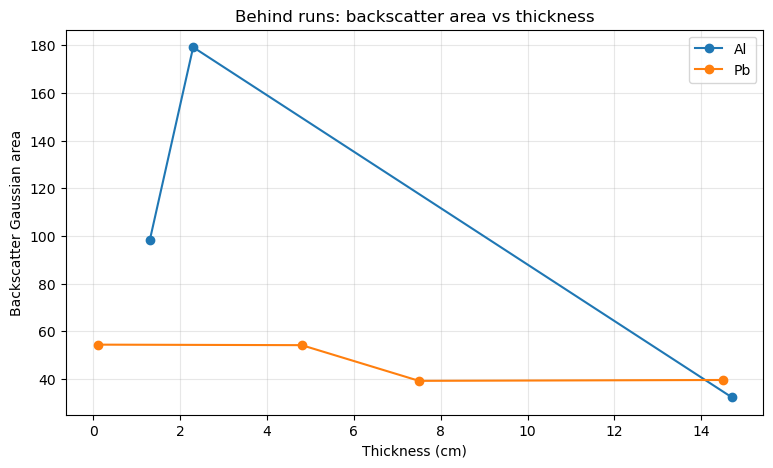

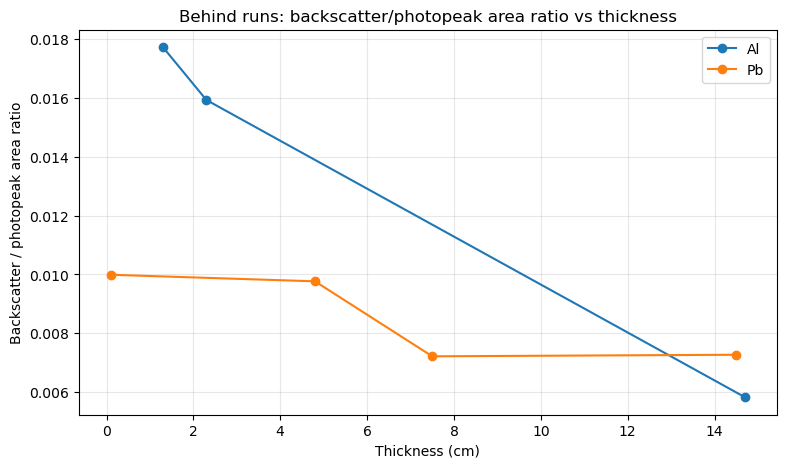

In [13]:

# -----------------------------
# ANALYSIS 1: BEHIND-RUN BACKSCATTER ENHANCEMENT
# -----------------------------

behind_df = subset_plot_data(analysis_df, geometry_position="behind")
display(behind_df[[
    "file",
    "material",
    "thickness_cm",
    "gaussian_area_counts__backscatter_peak",
    "amplitude_counts_per_s__backscatter_peak",
    "backscatter_to_photopeak_area_ratio",
    "backscatter_to_photopeak_amp_ratio",
]])

grouped_line_plot(
    behind_df,
    xcol="thickness_cm",
    ycol="gaussian_area_counts__backscatter_peak",
    groupcol="material",
    title="Behind runs: backscatter area vs thickness",
    xlabel="Thickness (cm)",
    ylabel="Backscatter Gaussian area",
)

grouped_line_plot(
    behind_df,
    xcol="thickness_cm",
    ycol="backscatter_to_photopeak_area_ratio",
    groupcol="material",
    title="Behind runs: backscatter/photopeak area ratio vs thickness",
    xlabel="Thickness (cm)",
    ylabel="Backscatter / photopeak area ratio",
)

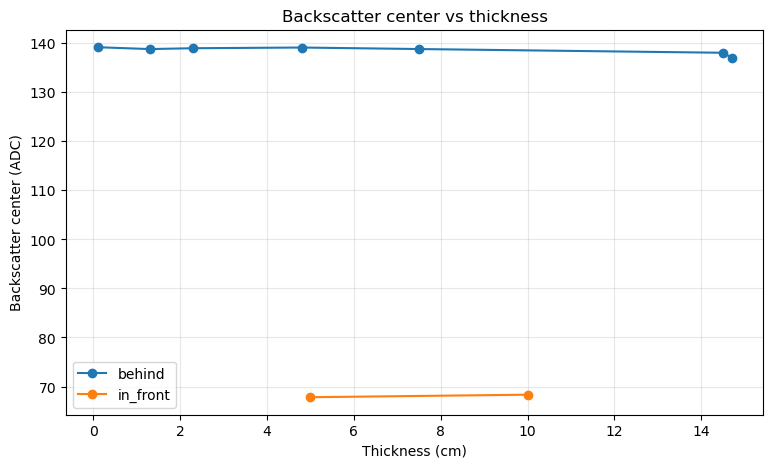

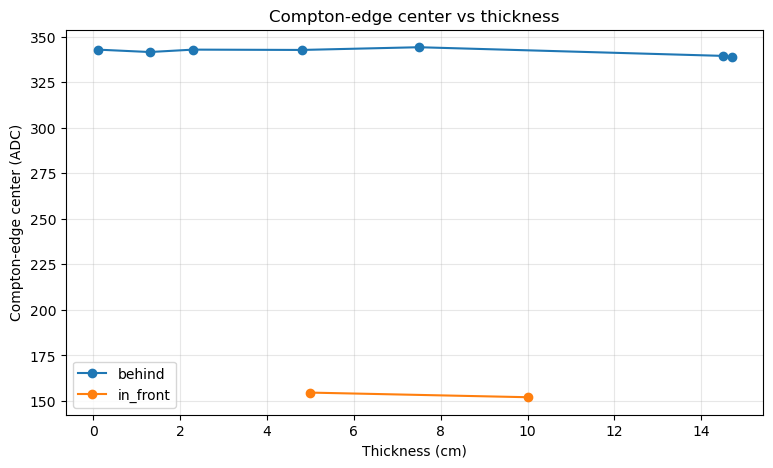

In [14]:

# -----------------------------
# ANALYSIS 2: BACKSCATTER / EDGE POSITION SHIFTS
# -----------------------------

thickness_df = analysis_df[analysis_df["geometry_position"].isin(["behind", "in_front"])].copy()

grouped_line_plot(
    thickness_df,
    xcol="thickness_cm",
    ycol="center_ADC__backscatter_peak",
    groupcol="geometry_position",
    title="Backscatter center vs thickness",
    xlabel="Thickness (cm)",
    ylabel="Backscatter center (ADC)",
)

grouped_line_plot(
    thickness_df,
    xcol="thickness_cm",
    ycol="center_ADC__compton_edge",
    groupcol="geometry_position",
    title="Compton-edge center vs thickness",
    xlabel="Thickness (cm)",
    ylabel="Compton-edge center (ADC)",
)

Slope columns: ['compton_region_slope_counts_per_s_per_ADC__backscatter_peak', 'compton_region_slope_counts_per_s_per_ADC__compton_edge']
Length columns: ['compton_region_length_ADC__backscatter_peak', 'compton_region_length_ADC__compton_edge', 'compton_region_length_ADC_err__backscatter_peak', 'compton_region_length_ADC_err__compton_edge']


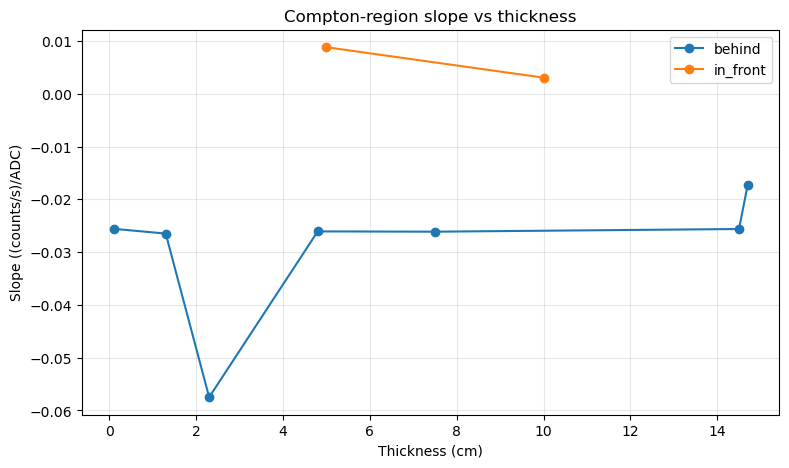

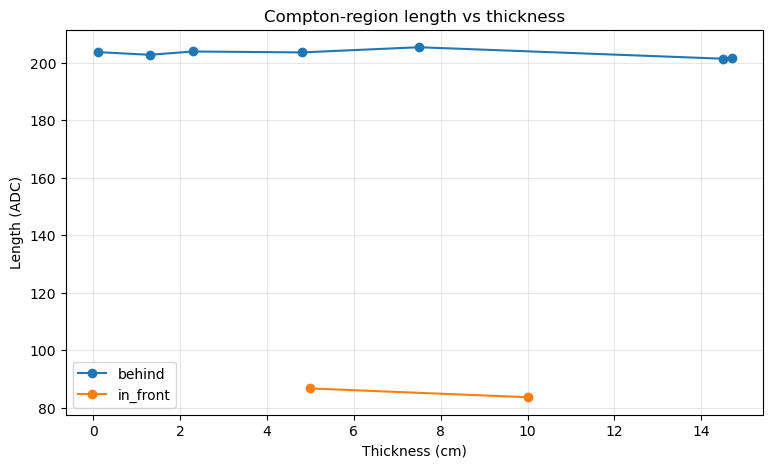

In [15]:

# -----------------------------
# ANALYSIS 3: COMPTON-CONTINUUM SHAPE
# -----------------------------

# Note:
# after pivoting, the compton-region columns live under one feature branch.
# Either feature branch should hold the same per-file region metrics.
slope_col_candidates = [
    c for c in analysis_df.columns
    if c.startswith("compton_region_slope_counts_per_s_per_ADC")
]
length_col_candidates = [
    c for c in analysis_df.columns
    if c.startswith("compton_region_length_ADC")
]

print("Slope columns:", slope_col_candidates)
print("Length columns:", length_col_candidates)

slope_col = slope_col_candidates[0]
length_col = [c for c in length_col_candidates if not c.endswith("_err")][0]

grouped_line_plot(
    thickness_df,
    xcol="thickness_cm",
    ycol=slope_col,
    groupcol="geometry_position",
    title="Compton-region slope vs thickness",
    xlabel="Thickness (cm)",
    ylabel="Slope ((counts/s)/ADC)",
)

grouped_line_plot(
    thickness_df,
    xcol="thickness_cm",
    ycol=length_col,
    groupcol="geometry_position",
    title="Compton-region length vs thickness",
    xlabel="Thickness (cm)",
    ylabel="Length (ADC)",
)

,file,day,center_ADC__backscatter_peak,center_ADC__compton_edge,photopeak_center_ADC
3,calibration/feb_24/preamp_0/Cs_22.1C_preamp0_f...,feb24,146.828851,332.599207,505.196312
4,cs gain setting/Cs_possible_calcurve_feb_24.csv,feb24,144.965989,336.736137,NaN
6,data/feb_26/cs137/Cs_22.4C_feb26_run1.csv,feb26,138.219695,333.658943,503.190803
7,data/mar_3/cs137/Cs_22.5C_mar3_run1.csv,mar3,154.441353,324.390000,505.105909
8,data/mar_5/cs137/Cs_21.9C_mar5_run1.csv,mar5,151.985613,354.748548,505.214458
0,calibration/daily/Cs_21.9C_preamp0_mar5.csv,None,152.635832,340.547030,505.179638
1,calibration/daily/Cs_22.0C_preamp0_mar3.csv,None,155.014473,354.746429,505.671076
2,calibration/daily/Cs_22.4C_preamp0_feb26.csv,None,143.535067,340.503966,503.121706
5,cs gain setting/Cs_trial_feb_19.csv,None,129.030000,261.376175,NaN


TypeError: 'value' must be an instance of str or bytes, not a None

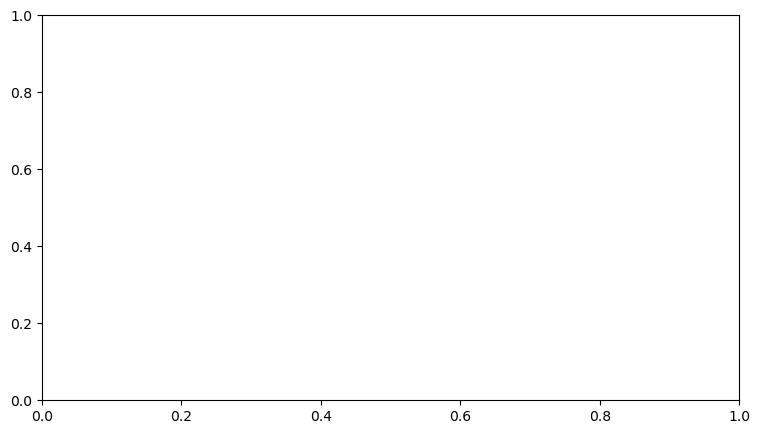

In [16]:

# -----------------------------
# ANALYSIS 4: ORDINARY CS STABILITY CONTROLS
# -----------------------------

standard_df = analysis_df[analysis_df["geometry_position"] == "standard"].copy()
display(standard_df[[
    "file",
    "day",
    "center_ADC__backscatter_peak",
    "center_ADC__compton_edge",
    "photopeak_center_ADC",
]].sort_values("day"))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(standard_df["day"], standard_df["photopeak_center_ADC"], "o-", label="photopeak")
ax.plot(standard_df["day"], standard_df["center_ADC__compton_edge"], "o-", label="Compton edge")
ax.plot(standard_df["day"], standard_df["center_ADC__backscatter_peak"], "o-", label="backscatter")
ax.set_title("Ordinary Cs runs: feature-center stability by day")
ax.set_xlabel("Day")
ax.set_ylabel("ADC center")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## One more analysis I think is worth doing

For the ugly `in_front` runs where the 662 keV peak is effectively gone, add a **window-integration analysis** that does not rely on a visible photopeak.

For each file, use the fitted backscatter and edge centers to define windows such as:

- below backscatter,
- around backscatter,
- between backscatter and edge,
- above edge.

Then compare the fractional counts in each window as thickness changes. That gives you a much more stable observable when traditional peak fitting breaks down.

In [17]:

# -----------------------------
# OPTIONAL WINDOW-INTEGRATION ANALYSIS
# -----------------------------

def load_spectrum(csv_path):
    with open(csv_path, "r", encoding="utf-8", errors="replace") as f:
        lines = f.readlines()

    metadata = {}
    data_start_idx = None

    for i, line in enumerate(lines):
        stripped = line.strip()
        if stripped == "Channel Data:":
            data_start_idx = i + 1
            break
        if "Elapsed Real Time:" in stripped:
            value = stripped.split("Elapsed Real Time:", 1)[1]
            value = value.split(",", 1)[1].strip() if "," in value else value.strip()
            metadata["Elapsed Real Time"] = value

    if data_start_idx is None:
        raise RuntimeError(f"Could not locate channel data block in {csv_path}")

    df = pd.read_csv(csv_path, skiprows=data_start_idx, header=None, names=["channel", "energy", "counts"])
    df = df.dropna(subset=["channel", "counts"])

    x = pd.to_numeric(df["channel"], errors="coerce").to_numpy(float)
    y = pd.to_numeric(df["counts"], errors="coerce").to_numpy(float)

    rt = metadata.get("Elapsed Real Time", None)
    match = re.search(r"[-+]?\d*\.?\d+", str(rt))
    live_time_s = float(match.group()) if match else np.nan

    return x, y, live_time_s

def counts_to_rate(counts, live_time_s):
    return np.asarray(counts, dtype=float) / float(live_time_s)

def background_subtracted_rate(sample_relpath, background_path=BACKGROUND_FILE):
    sample_path = ROOT / sample_relpath
    x_s, y_s, t_s = load_spectrum(sample_path)
    x_b, y_b, t_b = load_spectrum(background_path)

    if len(x_s) != len(x_b) or not np.allclose(x_s, x_b):
        raise RuntimeError("Sample/background grid mismatch.")

    return x_s, counts_to_rate(y_s, t_s) - counts_to_rate(y_b, t_b)

def integrate_window(x, y, xmin, xmax):
    mask = (x >= xmin) & (x <= xmax)
    if not np.any(mask):
        return np.nan
    return np.trapz(y[mask], x[mask])

window_rows = []

for _, row in analysis_df.iterrows():
    file = row["file"]
    back = row["center_ADC__backscatter_peak"]
    edge = row["center_ADC__compton_edge"]

    if not (np.isfinite(back) and np.isfinite(edge) and edge > back):
        continue

    x, y = background_subtracted_rate(file)

    total = integrate_window(x, y, x.min(), x.max())
    low = integrate_window(x, y, 0, back - 0.5 * (edge - back))
    around_back = integrate_window(x, y, back - 15, back + 15)
    continuum = integrate_window(x, y, back, edge)
    above_edge = integrate_window(x, y, edge, min(edge + 150, x.max()))

    window_rows.append({
        "file": file,
        "low_fraction": low / total if total else np.nan,
        "backscatter_window_fraction": around_back / total if total else np.nan,
        "continuum_fraction": continuum / total if total else np.nan,
        "above_edge_fraction": above_edge / total if total else np.nan,
    })

window_df = pd.DataFrame(window_rows)
window_analysis_df = analysis_df.merge(window_df, on="file", how="left")
display(window_analysis_df.head(20))

RuntimeError: Sample/background grid mismatch.

In [18]:

# -----------------------------
# EXAMPLE WINDOW-FRACTION PLOTS
# -----------------------------

window_thickness_df = window_analysis_df[window_analysis_df["geometry_position"].isin(["behind", "in_front"])].copy()

grouped_line_plot(
    window_thickness_df,
    xcol="thickness_cm",
    ycol="backscatter_window_fraction",
    groupcol="geometry_position",
    title="Backscatter-window fraction vs thickness",
    xlabel="Thickness (cm)",
    ylabel="Fraction of total background-subtracted counts",
)

grouped_line_plot(
    window_thickness_df,
    xcol="thickness_cm",
    ycol="continuum_fraction",
    groupcol="geometry_position",
    title="Compton-continuum fraction vs thickness",
    xlabel="Thickness (cm)",
    ylabel="Fraction of total background-subtracted counts",
)

NameError: name 'window_analysis_df' is not defined